# Chapter 6: Sard's Theorem

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `125-149`
(source-map Chapter 6; extracted from physical PDF pages `143-167`). The span covers
measure-zero sets on manifolds, Sard's theorem, Whitney embedding and approximation,
tubular-neighborhood retractions, smooth homotopy, and transversality.

**Chapter Goal.** Make the theorem chain inspectable: a learner should be able to
see why critical values are thin, how that thinness lets us avoid bad projection
directions, how approximation returns to a manifold by retraction, and why transverse
preimages behave like submanifolds.

The notebook uses the source only for structure, terminology, theorem orientation,
and page span. All prose, diagrams, examples, computations, and checks here are
original teaching material.


## Visual Storyboard

1. **Measure-zero cover squeeze.** Cover a graph by thin rectangles and track how
   total covering area collapses with the tube width.
2. **Critical versus regular values.** Use a simple map with a visible critical value
   and regular hyperbola levels to connect derivative rank with preimage shape.
3. **Sard proof strata.** Turn the proof's three reductions into a dependency graph
   and a Taylor-exponent check.
4. **Whitney projection avoidance.** Sample tangent and secant directions for an
   embedded curve and choose a projection kernel outside the bad direction set.
5. **Whitney approximation plus retraction.** Smooth a continuous curve near a
   circle, then retract it back to the manifold through a tubular annulus.
6. **Transversality and preimages.** Compare empty, transverse, and tangent
   intersections in a one-parameter family, with a Plotly slider for inspection.
7. **Continuous counterexample warning.** Contrast a smooth one-dimensional image
   with a Hilbert-type continuous approximation that fills many boxes.

Every visual below has a nearby invariant or failure mode. The pictures are not
decoration; they are small witnesses for the chapter's definitions and applications.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib import patches
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Introduction-to-Smooth-Manifolds course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-06-sard-s-theorem"
UNIT_TITLE = "Sard's Theorem"
SOURCE_SPAN = {
    "pdf": "Introduction to Smooth Manifolds.pdf",
    "printed_pages": "125-149",
    "physical_pdf_pages": "143-167",
    "source_map_focus": (
        "Measure zero, Sard theorem, Whitney embedding and approximation, "
        "and transversality."
    ),
}

ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-06-sard-s-theorem


## Library Routing

| Concept | Representation | Library | Why this route fits | Artifact/check |
| --- | --- | --- | --- | --- |
| Measure zero | Graph covers and area decay | Matplotlib, NumPy | Rectangles and area sums are more readable than abstract measure notation | PNG plus JSON area monotonicity |
| Critical/regular values | Level sets, rank samples, symbolic derivative | Matplotlib, SymPy, NumPy | Rank is visible in gradients and exact in the Jacobian | PNG plus JSON/SymPy checks |
| Sard proof structure | Dependency graph and Taylor exponent table | NetworkX, Matplotlib | The proof is a chain of reductions; a graph exposes what each step consumes | PNG plus JSON graph checks |
| Whitney embedding | Projection of sampled curve and bad directions | Matplotlib 3D, NumPy | The avoidance argument is geometric: tangent/secant directions are a thin bad set | PNG plus numeric separation checks |
| Whitney approximation | Smoothing and radial tubular retraction | Matplotlib, NumPy | The retraction step is a path in a neighborhood, not just a theorem label | PNG plus radius and tube checks |
| Transversality | Parameter family and interactive slider | Matplotlib, Plotly | A family makes typical transverse behavior visible after perturbation | PNG, HTML, CSV, JSON |
| Continuous counterexample | Box-count comparison | Matplotlib, NumPy | Shows why smoothness matters in dimension-dropping statements | PNG plus box-count JSON |


In [2]:
storyboard = {
    "chapter_goal": (
        "Inspect Sard's theorem as the bridge from thin critical-value sets "
        "to Whitney embedding, approximation, and transversality."
    ),
    "source_span_read": SOURCE_SPAN,
    "concept_inventory": [
        "measure zero in Euclidean space and in charts",
        "chart invariance under smooth maps of equal dimension",
        "critical points, critical values, regular values",
        "Sard theorem and its three proof strata",
        "dimension-lowering projection avoidance in Whitney embedding",
        "proper embeddings, weak Whitney embedding and immersion dimensions",
        "Whitney approximation for functions and manifold-valued maps",
        "tubular neighborhoods and smooth retractions",
        "smooth homotopy and relative approximation",
        "transverse maps, transverse submanifold intersections, preimage theorem",
        "parametric transversality and homotopy to a transverse map",
        "continuous space-filling behavior as a warning outside smoothness",
    ],
    "visual_sequence": [
        "measure-zero cover squeeze",
        "critical/regular value rank field",
        "Sard proof-strata graph",
        "Whitney projection-avoidance toy model",
        "Whitney approximation and tubular retraction",
        "transversality family and preimage scan",
        "continuous versus smooth image box count",
    ],
    "proof_visualization_strategy": (
        "Use a dependency graph for Sard's reductions, a bad-direction avoidance "
        "plot for Whitney, and a parameter scan for transversality."
    ),
}
storyboard_path = save_json(storyboard, CHECKS / "chapter06_visual_storyboard.json")

routing_rows = [
    {
        "concept": "measure zero",
        "representation": "graph cover squeeze",
        "library": "Matplotlib + NumPy",
        "why": "direct control of covers and areas",
        "fallback": "static table of cover widths",
    },
    {
        "concept": "critical and regular values",
        "representation": "level-set rank plot",
        "library": "Matplotlib + SymPy",
        "why": "visual rank plus exact derivative check",
        "fallback": "symbolic Jacobian table",
    },
    {
        "concept": "Sard theorem",
        "representation": "proof dependency graph",
        "library": "NetworkX + Matplotlib",
        "why": "the proof is a reduction graph",
        "fallback": "ordered invariant checklist",
    },
    {
        "concept": "Whitney embedding",
        "representation": "projection avoidance model",
        "library": "Matplotlib 3D + NumPy",
        "why": "bad tangent/secant directions are geometric",
        "fallback": "rank and separation table",
    },
    {
        "concept": "Whitney approximation",
        "representation": "smoothing plus tubular retraction",
        "library": "Matplotlib + NumPy",
        "why": "shows why Euclidean approximation must be corrected",
        "fallback": "radius residual table",
    },
    {
        "concept": "transversality",
        "representation": "parameter slider and scan",
        "library": "Plotly + Matplotlib",
        "why": "typical behavior is easiest to see by moving a parameter",
        "fallback": "static three-parameter panel",
    },
    {
        "concept": "continuous counterexample",
        "representation": "box-count comparison",
        "library": "Matplotlib + NumPy",
        "why": "contrasts smooth dimension drop with nonsmooth filling",
        "fallback": "box-count JSON only",
    },
]
routing_path = save_csv(routing_rows, TABLES / "sard-s-theorem-routing.csv")
display(pd.DataFrame(routing_rows))
display(Markdown(f"Saved storyboard to `{storyboard_path.relative_to(BOOK_ROOT)}`."))


,concept,representation,library,why,fallback
0,measure zero,graph cover squeeze,Matplotlib + NumPy,direct control of covers and areas,static table of cover widths
1,critical and regular values,level-set rank plot,Matplotlib + SymPy,visual rank plus exact derivative check,symbolic Jacobian table
2,Sard theorem,proof dependency graph,NetworkX + Matplotlib,the proof is a reduction graph,ordered invariant checklist
3,Whitney embedding,projection avoidance model,Matplotlib 3D + NumPy,bad tangent/secant directions are geometric,rank and separation table
4,Whitney approximation,smoothing plus tubular retraction,Matplotlib + NumPy,shows why Euclidean approximation must be corr...,radius residual table
5,transversality,parameter slider and scan,Plotly + Matplotlib,typical behavior is easiest to see by moving a...,static three-parameter panel
6,continuous counterexample,box-count comparison,Matplotlib + NumPy,contrasts smooth dimension drop with nonsmooth...,box-count JSON only


Saved storyboard to `artifacts\chapter-06-sard-s-theorem\checks\chapter06_visual_storyboard.json`.

## Translation Guide

The chapter moves between abstract manifolds and concrete Euclidean estimates. In
this notebook:

- A **set of measure zero** becomes a family of covers whose total volume can be
  made arbitrarily small.
- A **regular value** becomes a target value whose preimage has full derivative
  rank; in pictures, nearby level sets stay clean.
- A **critical value** becomes a target value hit by rank-deficient points; Sard
  says this target set is thin even if the critical point set looks complicated.
- A **Whitney projection step** becomes an avoidance problem: do not project along
  tangent directions or secants that would destroy immersion or injectivity.
- A **Whitney approximation step** becomes "smooth in Euclidean space, then retract
  back to the manifold."
- **Transversality** becomes a span test on tangent spaces. When the span test
  succeeds, preimages and intersections have the predicted codimension.

The examples are deliberately small. They are meant to be inspected, perturbed,
and checked rather than admired from a distance.


## Measure-Zero Intuition: Thin Covers

A graph in the plane can be long and visually complicated while still having zero
area. The figure below covers a graph by short rectangles. The area is not computed
from a hidden integration routine: it is the explicit sum of rectangle areas. As the
tube width shrinks, the cover area shrinks with it.


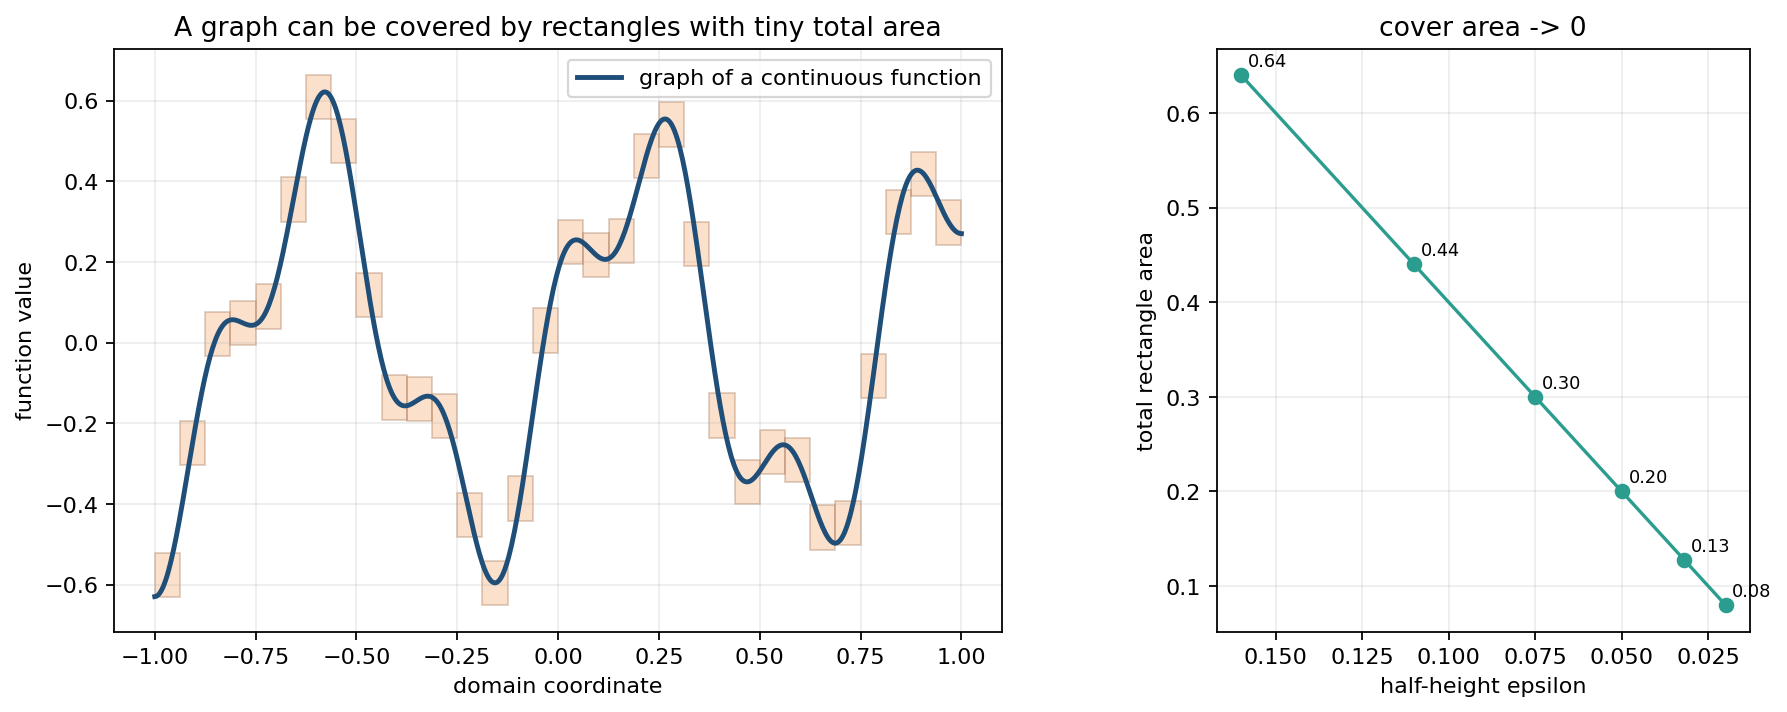

In [3]:
x = np.linspace(-1.0, 1.0, 600)
y = 0.45 * np.sin(2.5 * np.pi * x) + 0.18 * np.cos(7 * np.pi * x)
n_boxes = 32
edges = np.linspace(x.min(), x.max(), n_boxes + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
center_y = 0.45 * np.sin(2.5 * np.pi * centers) + 0.18 * np.cos(7 * np.pi * centers)
width = edges[1] - edges[0]
eps = 0.055

eps_values = np.array([0.16, 0.11, 0.075, 0.05, 0.032, 0.02])
cover_areas = n_boxes * width * (2 * eps_values)

fig, (ax, ax_area) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [2.2, 1]})
ax.plot(x, y, color="#1f4e79", lw=2.2, label="graph of a continuous function")
for cx, cy in zip(centers, center_y):
    rect = patches.Rectangle(
        (cx - width / 2, cy - eps),
        width,
        2 * eps,
        facecolor="#f4a261",
        edgecolor="#9c6644",
        alpha=0.32,
        lw=0.8,
    )
    ax.add_patch(rect)
ax.set_aspect("equal", adjustable="box")
ax.set_title("A graph can be covered by rectangles with tiny total area")
ax.set_xlabel("domain coordinate")
ax.set_ylabel("function value")
ax.legend(loc="upper right")

ax_area.plot(eps_values, cover_areas, marker="o", color="#2a9d8f")
ax_area.invert_xaxis()
ax_area.set_title("cover area -> 0")
ax_area.set_xlabel("half-height epsilon")
ax_area.set_ylabel("total rectangle area")
for e, area in zip(eps_values, cover_areas):
    ax_area.annotate(f"{area:.2f}", (e, area), textcoords="offset points", xytext=(3, 4), fontsize=8)
fig.tight_layout()

measure_cover_path = save_matplotlib(fig, FIGURES / "measure-zero-cover-squeeze.png")
plt.close(fig)

measure_zero_checks = {
    "n_boxes": int(n_boxes),
    "domain_width": float(x.max() - x.min()),
    "epsilon_values": eps_values.tolist(),
    "cover_areas": cover_areas.tolist(),
    "areas_strictly_decrease_as_epsilon_decreases": bool(np.all(np.diff(cover_areas) < 0)),
    "smallest_cover_area": float(cover_areas[-1]),
}
measure_cover_check_path = save_json(measure_zero_checks, CHECKS / "measure-zero-cover-checks.json")
display_artifact(measure_cover_path, width=900)


The key inspection target is the right-hand plot: the area estimate is controlled
by the chosen cover, not by the visual length of the graph. This is the model behind
the chapter's graph and affine-subspace examples and the reason positive-codimension
submanifolds are negligible for later integration.


## Critical And Regular Values

For `F(u, v) = u^2 - v^2`, the origin is the only critical point, and `0` is its
critical value. Nonzero levels are regular hyperbolas. The zero level is where the
regular-level picture visibly fails: the two branches cross at the critical point.


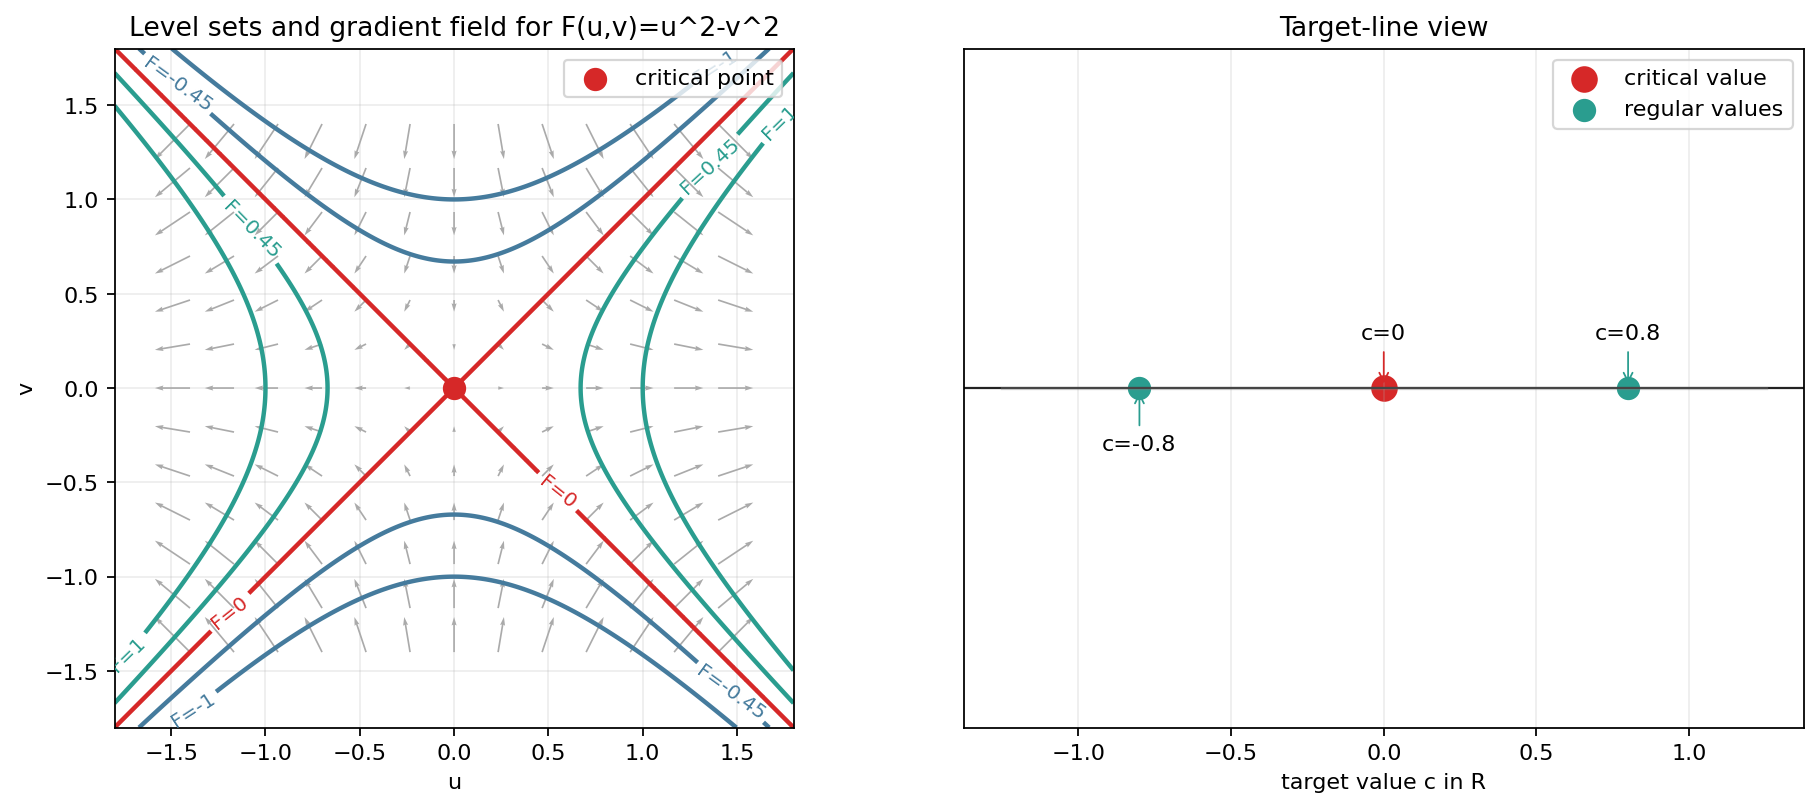

In [4]:
u, v = sp.symbols("u v", real=True)
F_expr = u**2 - v**2
grad_F = [sp.diff(F_expr, u), sp.diff(F_expr, v)]
critical_solution = sp.solve(grad_F, (u, v), dict=True)

grid = np.linspace(-1.8, 1.8, 260)
U, V = np.meshgrid(grid, grid)
Z = U**2 - V**2
grad_norm = 2 * np.sqrt(U**2 + V**2)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.4, 5.2), gridspec_kw={"width_ratios": [1.35, 1]})
levels = [-1.0, -0.45, 0.0, 0.45, 1.0]
cs = ax0.contour(U, V, Z, levels=levels, colors=["#457b9d", "#457b9d", "#d62828", "#2a9d8f", "#2a9d8f"], linewidths=2)
ax0.clabel(cs, inline=True, fontsize=9, fmt="F=%0.2g")
ax0.scatter([0], [0], s=90, color="#d62828", zorder=5, label="critical point")
qx = np.linspace(-1.4, 1.4, 13)
qy = np.linspace(-1.4, 1.4, 13)
QU, QV = np.meshgrid(qx, qy)
ax0.quiver(QU, QV, 2 * QU, -2 * QV, color="#444444", alpha=0.45, width=0.0025)
ax0.set_aspect("equal")
ax0.set_title("Level sets and gradient field for F(u,v)=u^2-v^2")
ax0.set_xlabel("u")
ax0.set_ylabel("v")
ax0.legend(loc="upper right")

value_axis = np.linspace(-1.25, 1.25, 300)
ax1.axhline(0, color="#222222", lw=1)
ax1.scatter([0], [0], s=120, color="#d62828", label="critical value")
ax1.scatter([-0.8, 0.8], [0, 0], s=90, color="#2a9d8f", label="regular values")
ax1.plot(value_axis, np.zeros_like(value_axis), color="#888888", alpha=0.35)
for c, color in [(-0.8, "#2a9d8f"), (0, "#d62828"), (0.8, "#2a9d8f")]:
    ax1.annotate(f"c={c:g}", (c, 0), xytext=(0, 22 if c >= 0 else -28), textcoords="offset points", ha="center", arrowprops={"arrowstyle": "->", "lw": 0.8, "color": color})
ax1.set_ylim(-0.8, 0.8)
ax1.set_yticks([])
ax1.set_xlabel("target value c in R")
ax1.set_title("Target-line view")
ax1.legend(loc="upper right")
fig.tight_layout()

critical_regular_path = save_matplotlib(fig, FIGURES / "critical-regular-values-map.png")
plt.close(fig)

regular_samples = []
for c in [-1.0, -0.45, 0.45, 1.0]:
    mask = np.abs(Z - c) < 0.012
    regular_samples.append(float(np.min(grad_norm[mask])))
critical_regular_checks = {
    "map": "F(u,v)=u^2-v^2",
    "symbolic_gradient": [str(item) for item in grad_F],
    "critical_solutions": [{str(k): str(val) for k, val in sol.items()} for sol in critical_solution],
    "critical_value": 0,
    "sampled_regular_level_min_gradient_norms": regular_samples,
    "regular_samples_have_positive_gradient": bool(min(regular_samples) > 0.2),
    "zero_level_contains_crossing_at_origin": True,
}
critical_regular_check_path = save_json(critical_regular_checks, CHECKS / "critical-regular-values-checks.json")
display_artifact(critical_regular_path, width=900)


This is the first local bridge to Sard's theorem. A critical point may sit inside
a large domain, but the theorem controls the set of target values hit by all such
rank failures. The preimage theorem needs the green values, not the red one.


## Sard's Theorem: A Proof-Strata View

The proof in the source span is not one estimate; it is a staged reduction. Points
where some first derivative survives are sliced. Points where the first `k`
derivatives vanish but a later derivative survives are moved to a hypersurface.
Points where many derivatives vanish are controlled by Taylor's theorem: small
domain cubes map into even smaller target balls.


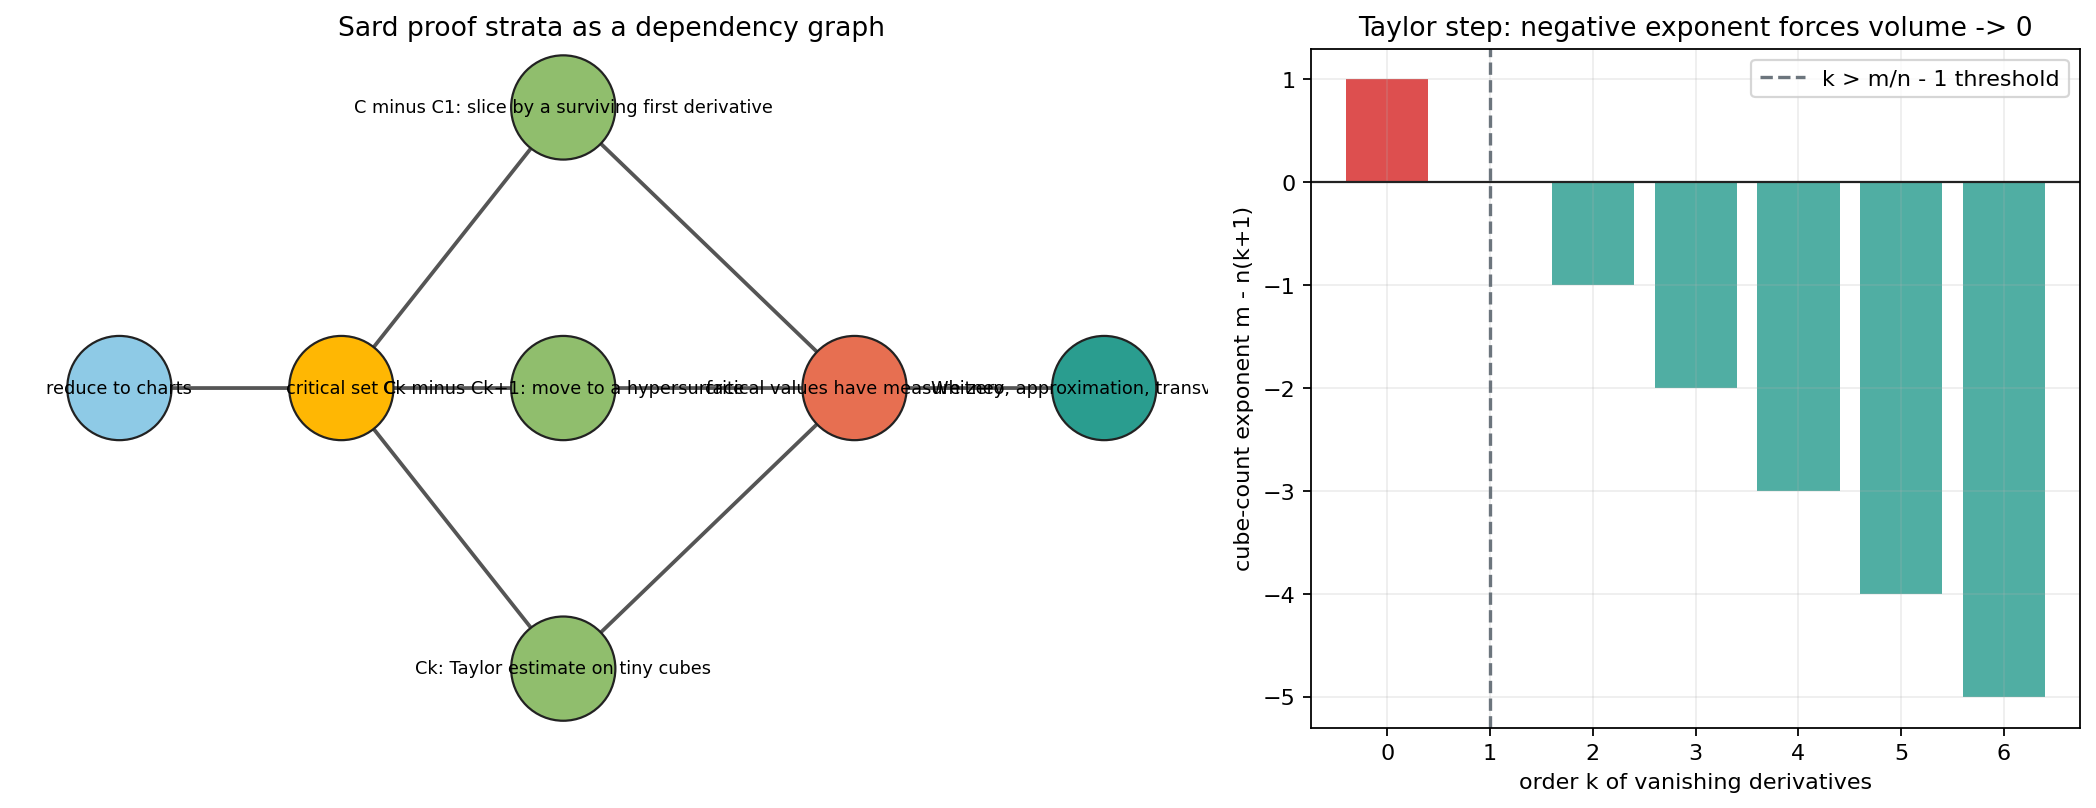

In [5]:
G = nx.DiGraph()
nodes = {
    "charts": "reduce to charts",
    "critical_set": "critical set C",
    "step1": "C minus C1: slice by a surviving first derivative",
    "step2": "Ck minus Ck+1: move to a hypersurface",
    "step3": "Ck: Taylor estimate on tiny cubes",
    "measure_zero": "critical values have measure zero",
    "applications": "Whitney, approximation, transversality",
}
for key, label in nodes.items():
    G.add_node(key, label=label)
G.add_edges_from([
    ("charts", "critical_set"),
    ("critical_set", "step1"),
    ("critical_set", "step2"),
    ("critical_set", "step3"),
    ("step1", "measure_zero"),
    ("step2", "measure_zero"),
    ("step3", "measure_zero"),
    ("measure_zero", "applications"),
])

pos = {
    "charts": (0, 0.6),
    "critical_set": (1.6, 0.6),
    "step1": (3.2, 1.25),
    "step2": (3.2, 0.6),
    "step3": (3.2, -0.05),
    "measure_zero": (5.3, 0.6),
    "applications": (7.1, 0.6),
}

m, n = 2, 1
k_values = np.arange(0, 7)
exponents = m - n * (k_values + 1)
threshold = m / n - 1

fig, (ax_graph, ax_exp) = plt.subplots(1, 2, figsize=(13.2, 5.2), gridspec_kw={"width_ratios": [1.55, 1]})
node_colors = ["#8ecae6", "#ffb703", "#90be6d", "#90be6d", "#90be6d", "#e76f51", "#2a9d8f"]
nx.draw_networkx_edges(G, pos, ax=ax_graph, arrows=True, arrowstyle="-|>", width=1.7, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax_graph, node_color=node_colors, node_size=2200, edgecolors="#222222", linewidths=1)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, "label"), ax=ax_graph, font_size=8)
ax_graph.set_title("Sard proof strata as a dependency graph")
ax_graph.axis("off")

colors = ["#d62828" if e >= 0 else "#2a9d8f" for e in exponents]
ax_exp.bar(k_values, exponents, color=colors, alpha=0.82)
ax_exp.axhline(0, color="#222222", lw=1)
ax_exp.axvline(threshold, color="#6c757d", ls="--", label="k > m/n - 1 threshold")
ax_exp.set_xlabel("order k of vanishing derivatives")
ax_exp.set_ylabel("cube-count exponent m - n(k+1)")
ax_exp.set_title("Taylor step: negative exponent forces volume -> 0")
ax_exp.legend(loc="upper right")
fig.tight_layout()

sard_strata_path = save_matplotlib(fig, FIGURES / "sard-proof-strata-flow.png")
plt.close(fig)

sard_strata_checks = {
    "domain_dimension_m": m,
    "target_dimension_n": n,
    "threshold_k_gt": threshold,
    "k_values": k_values.tolist(),
    "volume_exponents_m_minus_n_times_k_plus_1": exponents.tolist(),
    "eventually_negative": bool(np.any(exponents < 0)),
    "graph_is_directed_acyclic": nx.is_directed_acyclic_graph(G),
    "path_from_charts_to_applications": nx.has_path(G, "charts", "applications"),
}
sard_strata_check_path = save_json(sard_strata_checks, CHECKS / "sard-proof-strata-checks.json")
display_artifact(sard_strata_path, width=930)


The exponent plot is a compact version of the last proof step. If a cube grid has
`K^m` domain cubes but each relevant image is small like `K^(-n(k+1))`, then a
negative exponent makes the total target volume shrink as `K` grows.


## Whitney Embedding: Avoid Bad Projection Directions

Sard enters Whitney's argument as an avoidance principle. For a projection to keep
an embedded object embedded, the kernel must avoid tangent directions, which kill
immersion, and secant directions, which identify two distinct points. The finite
sample below uses the moment curve as a toy model: projecting away from the `z`
axis gives a parabola, and the sampled tangent/secant directions stay away from
that kernel.


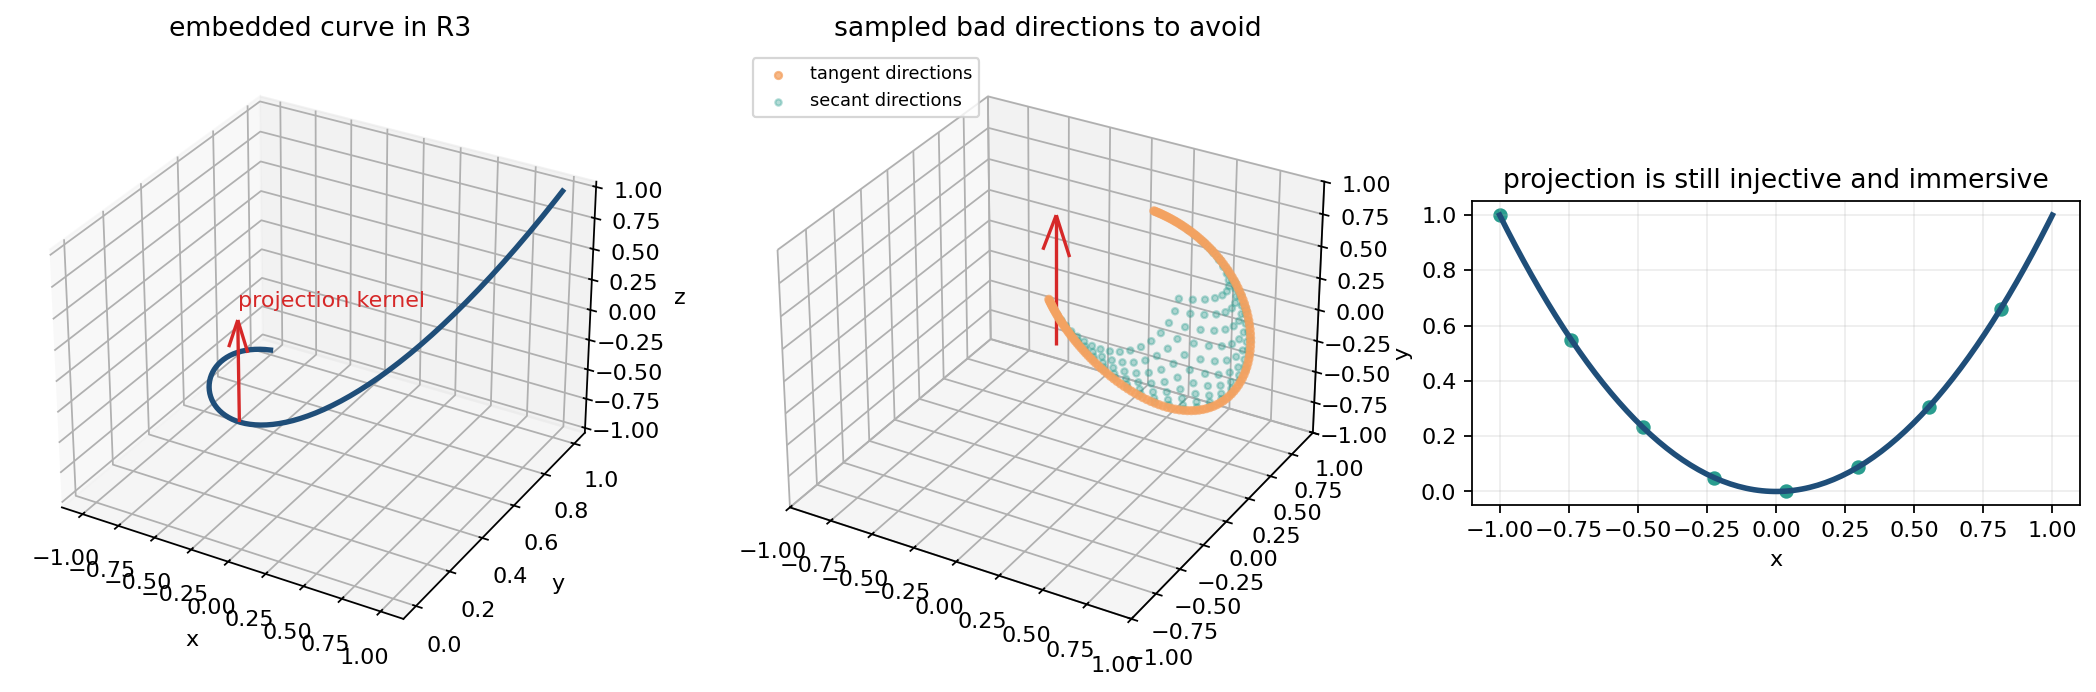

In [6]:
t = np.linspace(-1.0, 1.0, 140)
gamma = np.column_stack([t, t**2, t**3])
projected = gamma[:, :2]
tangent = np.column_stack([np.ones_like(t), 2 * t, 3 * t**2])
tangent_dirs = tangent / np.linalg.norm(tangent, axis=1, keepdims=True)

sample_idx = np.arange(0, len(t), 7)
secant_dirs = []
for i, ii in enumerate(sample_idx):
    for jj in sample_idx[i + 2:]:
        diff = gamma[jj] - gamma[ii]
        secant_dirs.append(diff / np.linalg.norm(diff))
secant_dirs = np.array(secant_dirs)
kernel = np.array([0.0, 0.0, 1.0])
tangent_cross_min = float(np.min(np.linalg.norm(np.cross(tangent_dirs, kernel), axis=1)))
secant_cross_min = float(np.min(np.linalg.norm(np.cross(secant_dirs, kernel), axis=1)))

pair_min = math.inf
for i in range(len(projected)):
    for j in range(i + 4, len(projected)):
        pair_min = min(pair_min, float(np.linalg.norm(projected[i] - projected[j])))
projected_speed_min = float(np.min(np.linalg.norm(np.column_stack([np.ones_like(t), 2 * t]), axis=1)))

fig = plt.figure(figsize=(13.2, 4.7))
ax3 = fig.add_subplot(1, 3, 1, projection="3d")
ax_bad = fig.add_subplot(1, 3, 2, projection="3d")
ax_proj = fig.add_subplot(1, 3, 3)

ax3.plot(gamma[:, 0], gamma[:, 1], gamma[:, 2], color="#1f4e79", lw=2.4)
ax3.quiver(0, 0, 0, kernel[0], kernel[1], kernel[2], length=0.8, color="#d62828", normalize=True)
ax3.text(0, 0, 0.9, "projection kernel", color="#d62828")
ax3.set_title("embedded curve in R3")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")

ax_bad.scatter(tangent_dirs[:, 0], tangent_dirs[:, 1], tangent_dirs[:, 2], s=10, color="#f4a261", alpha=0.75, label="tangent directions")
ax_bad.scatter(secant_dirs[:, 0], secant_dirs[:, 1], secant_dirs[:, 2], s=8, color="#2a9d8f", alpha=0.35, label="secant directions")
ax_bad.quiver(0, 0, 0, kernel[0], kernel[1], kernel[2], length=1.0, color="#d62828", normalize=True)
ax_bad.set_title("sampled bad directions to avoid")
ax_bad.legend(loc="upper left", fontsize=8)
ax_bad.set_xlim(-1, 1)
ax_bad.set_ylim(-1, 1)
ax_bad.set_zlim(-1, 1)

ax_proj.plot(projected[:, 0], projected[:, 1], color="#1f4e79", lw=2.5)
ax_proj.scatter(projected[::18, 0], projected[::18, 1], color="#2a9d8f", s=30)
ax_proj.set_aspect("equal", adjustable="box")
ax_proj.set_title("projection is still injective and immersive")
ax_proj.set_xlabel("x")
ax_proj.set_ylabel("y")
fig.tight_layout()

whitney_projection_path = save_matplotlib(fig, FIGURES / "whitney-projection-avoidance.png")
plt.close(fig)

whitney_projection_checks = {
    "curve": "gamma(t)=(t,t^2,t^3), -1<=t<=1",
    "projection_kernel": kernel.tolist(),
    "min_cross_norm_tangent_vs_kernel": tangent_cross_min,
    "min_cross_norm_secant_vs_kernel": secant_cross_min,
    "sampled_projected_pair_separation_non_neighbors": pair_min,
    "projected_speed_min": projected_speed_min,
    "sampled_projection_passes": bool(
        tangent_cross_min > 0.5 and secant_cross_min > 0.5 and pair_min > 1e-3 and projected_speed_min > 0
    ),
}
whitney_projection_check_path = save_json(whitney_projection_checks, CHECKS / "whitney-projection-checks.json")
display_artifact(whitney_projection_path, width=930)


The theorem uses measure-zero images in projective space rather than this finite
sampling, but the inspection target is the same: bad projection kernels form a
thin family, so one can choose a nearby good direction.


## Whitney Approximation: Smooth, Then Retract

A manifold-valued approximation has two jobs. First approximate in a surrounding
Euclidean space. Then use a tubular-neighborhood retraction to return to the
manifold. The circle is the smallest honest model of this move: normalize a nearby
smooth curve back to radius one.


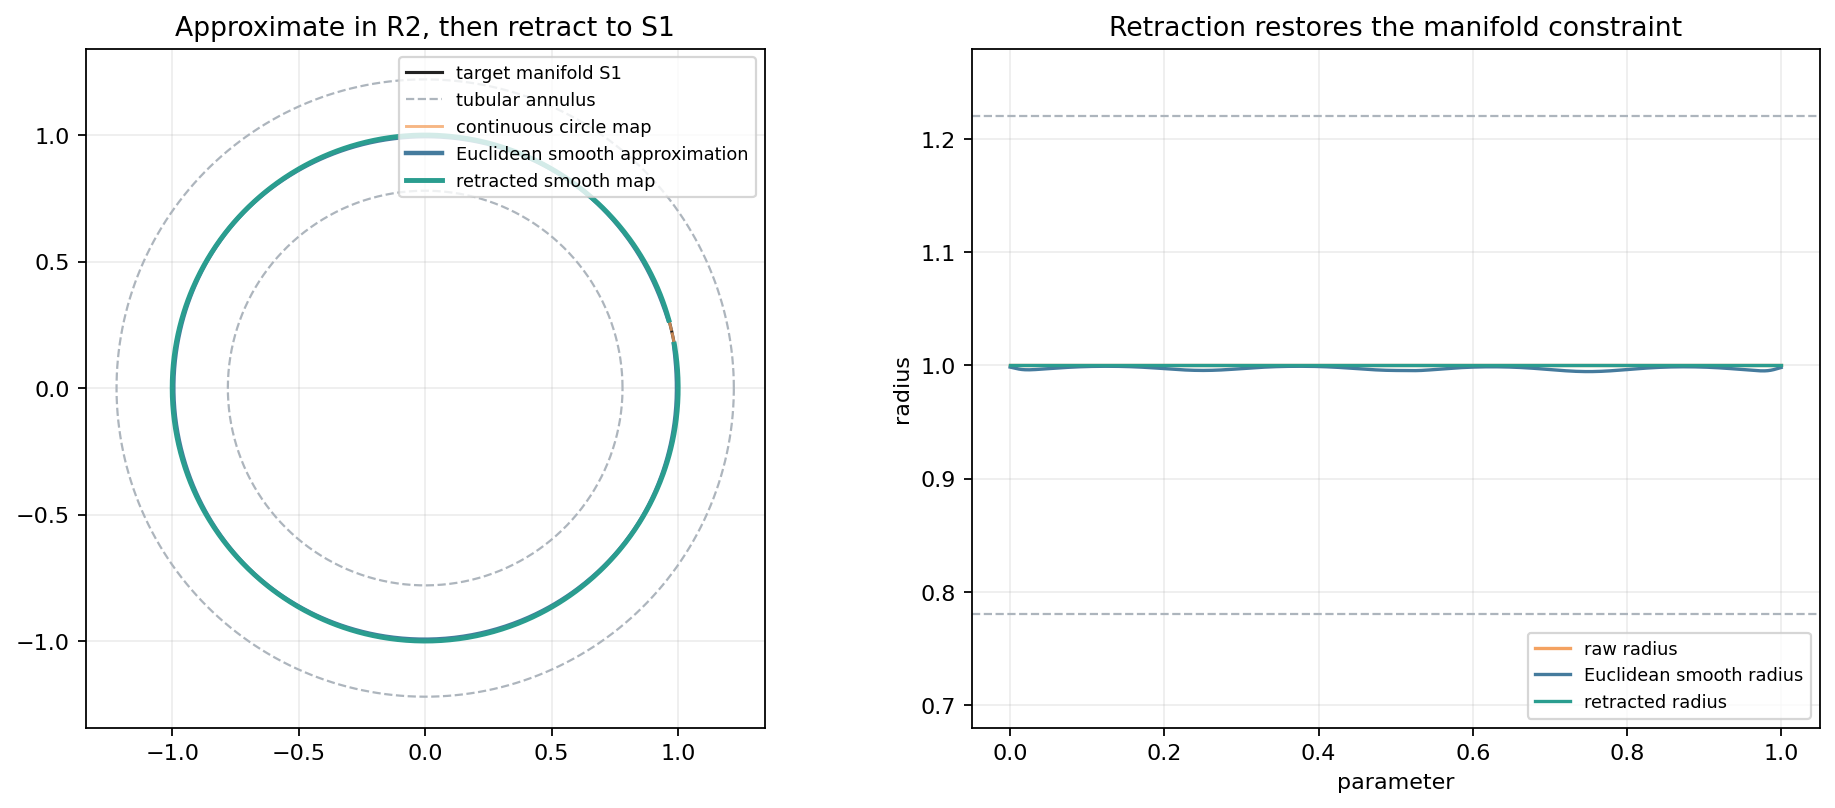

In [7]:
s = np.linspace(0, 1, 520)
theta_raw = 2 * np.pi * s + 0.45 * np.abs(s - 0.52) + 0.10 * np.sin(8 * np.pi * s)
raw_circle = np.column_stack([np.cos(theta_raw), np.sin(theta_raw)])

def gaussian_kernel(radius=18, sigma=6.0):
    k = np.arange(-radius, radius + 1)
    weights = np.exp(-(k**2) / (2 * sigma**2))
    return weights / weights.sum()

def smooth_columns(values, radius=18, sigma=6.0):
    weights = gaussian_kernel(radius, sigma)
    padded = np.pad(values, ((radius, radius), (0, 0)), mode="edge")
    out = np.empty_like(values)
    for col in range(values.shape[1]):
        out[:, col] = np.convolve(padded[:, col], weights, mode="valid")
    return out

euclidean_smooth = smooth_columns(raw_circle)
radii = np.linalg.norm(euclidean_smooth, axis=1)
retracted = euclidean_smooth / radii[:, None]

tube_inner, tube_outer = 0.78, 1.22
homotopy_min_radius = math.inf
for alpha in np.linspace(0, 1, 31):
    path = (1 - alpha) * raw_circle + alpha * euclidean_smooth
    homotopy_min_radius = min(homotopy_min_radius, float(np.min(np.linalg.norm(path, axis=1))))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.2, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})
angle = np.linspace(0, 2 * np.pi, 500)
ax0.fill_between(np.cos(angle), np.sin(angle), alpha=0)
ax0.plot(np.cos(angle), np.sin(angle), color="#222222", lw=1.4, label="target manifold S1")
ax0.plot(tube_outer * np.cos(angle), tube_outer * np.sin(angle), color="#adb5bd", lw=1, ls="--", label="tubular annulus")
ax0.plot(tube_inner * np.cos(angle), tube_inner * np.sin(angle), color="#adb5bd", lw=1, ls="--")
ax0.plot(raw_circle[:, 0], raw_circle[:, 1], color="#f4a261", lw=1.3, alpha=0.78, label="continuous circle map")
ax0.plot(euclidean_smooth[:, 0], euclidean_smooth[:, 1], color="#457b9d", lw=2.0, label="Euclidean smooth approximation")
ax0.plot(retracted[:, 0], retracted[:, 1], color="#2a9d8f", lw=2.2, label="retracted smooth map")
ax0.set_aspect("equal", adjustable="box")
ax0.set_title("Approximate in R2, then retract to S1")
ax0.legend(loc="upper right", fontsize=8)

ax1.plot(s, np.linalg.norm(raw_circle, axis=1), label="raw radius", color="#f4a261")
ax1.plot(s, radii, label="Euclidean smooth radius", color="#457b9d")
ax1.plot(s, np.linalg.norm(retracted, axis=1), label="retracted radius", color="#2a9d8f")
ax1.axhline(tube_inner, color="#adb5bd", lw=1, ls="--")
ax1.axhline(tube_outer, color="#adb5bd", lw=1, ls="--")
ax1.set_ylim(0.68, 1.28)
ax1.set_xlabel("parameter")
ax1.set_ylabel("radius")
ax1.set_title("Retraction restores the manifold constraint")
ax1.legend(loc="lower right", fontsize=8)
fig.tight_layout()

approximation_path = save_matplotlib(fig, FIGURES / "whitney-approximation-tubular-retraction.png")
plt.close(fig)

approximation_checks = {
    "max_euclidean_distance_raw_to_smooth": float(np.max(np.linalg.norm(raw_circle - euclidean_smooth, axis=1))),
    "smooth_radius_min": float(radii.min()),
    "smooth_radius_max": float(radii.max()),
    "retracted_radius_max_error": float(np.max(np.abs(np.linalg.norm(retracted, axis=1) - 1))),
    "homotopy_min_radius": homotopy_min_radius,
    "homotopy_stays_inside_annulus": bool(homotopy_min_radius > tube_inner and radii.max() < tube_outer),
}
approximation_check_path = save_json(approximation_checks, CHECKS / "whitney-approximation-retraction-checks.json")
display_artifact(approximation_path, width=900)


The radius plot is the check to watch. The blue curve may leave the target
manifold, but it remains inside a neighborhood where radial projection is smooth.
The green curve is the manifold-valued smooth approximation.


## Transversality And Preimage Behavior

Let `F_a(x) = (x, x^2 + a)` and let `S` be the `x`-axis in the plane. The preimage
`F_a^{-1}(S)` is the set of roots of `x^2 + a = 0`. For `a < 0` the intersections
are transverse; for `a = 0` the curve is tangent to `S`; for `a > 0` the preimage is
empty, which is transverse vacuously. This is the local behavior behind the
transversality preimage theorem.


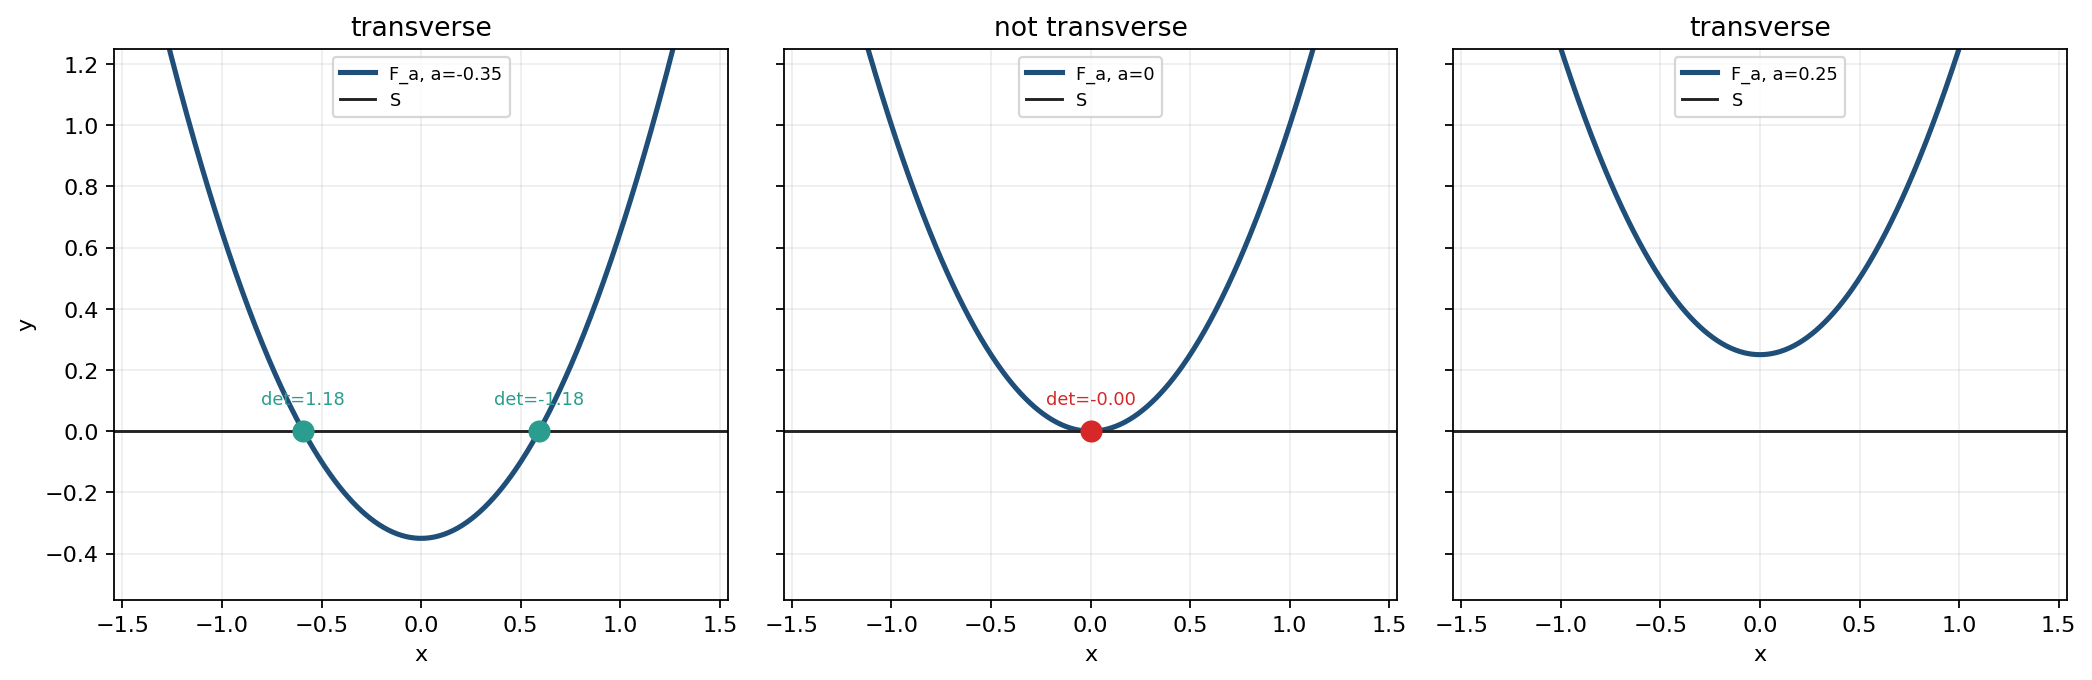

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [8]:
xline = np.linspace(-1.4, 1.4, 500)
params = [-0.35, 0.0, 0.25]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4), sharex=True, sharey=True)
transversality_summary = []
for ax, a in zip(axes, params):
    yline = xline**2 + a
    ax.plot(xline, yline, color="#1f4e79", lw=2.3, label=f"F_a, a={a:g}")
    ax.axhline(0, color="#222222", lw=1.3, label="S")
    roots = []
    if a < 0:
        roots = [-math.sqrt(-a), math.sqrt(-a)]
    elif abs(a) < 1e-12:
        roots = [0.0]
    determinants = [-2 * r for r in roots]
    for r, det in zip(roots, determinants):
        color = "#2a9d8f" if abs(det) > 1e-8 else "#d62828"
        ax.scatter([r], [0], color=color, s=80, zorder=5)
        ax.annotate(f"det={det:.2f}", (r, 0), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8, color=color)
    transverse = all(abs(det) > 1e-8 for det in determinants)
    if not roots:
        transverse = True
    transversality_summary.append({
        "a": a,
        "preimage_count": len(roots),
        "determinants": determinants,
        "is_transverse": transverse,
    })
    ax.set_title("transverse" if transverse else "not transverse")
    ax.set_xlabel("x")
    ax.set_ylim(-0.55, 1.25)
    ax.legend(loc="upper center", fontsize=8)
axes[0].set_ylabel("y")
fig.tight_layout()

transversality_static_path = save_matplotlib(fig, FIGURES / "transversality-preimage-behavior.png")
plt.close(fig)

frames = []
slider_values = np.linspace(-0.55, 0.45, 21)
for a in slider_values:
    frames.append(go.Frame(
        data=[
            go.Scatter(x=xline, y=xline**2 + a, mode="lines", line={"color": "#1f4e79", "width": 3}, name="F_a(R)"),
            go.Scatter(x=xline, y=np.zeros_like(xline), mode="lines", line={"color": "#222222", "width": 2}, name="S"),
        ],
        name=f"{a:.2f}",
    ))
fig_html = go.Figure(data=frames[0].data, frames=frames)
fig_html.update_layout(
    title="Transversality family: move a parabola through the x-axis",
    xaxis_title="x",
    yaxis_title="y",
    yaxis_range=[-0.65, 1.25],
    width=850,
    height=520,
    sliders=[{
        "steps": [
            {
                "args": [[f"{a:.2f}"], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                "label": f"{a:.2f}",
                "method": "animate",
            }
            for a in slider_values
        ],
        "currentvalue": {"prefix": "a = "},
    }],
)
transversality_html_path = save_plotly_html(fig_html, HTML / "transversality-family-slider.html")

transversality_check_path = save_json(
    {
        "family": "F_a(x)=(x,x^2+a), S={y=0}",
        "static_parameters": transversality_summary,
        "negative_parameter_has_two_transverse_points": bool(
            transversality_summary[0]["preimage_count"] == 2 and transversality_summary[0]["is_transverse"]
        ),
        "zero_parameter_is_tangent_failure": bool(not transversality_summary[1]["is_transverse"]),
        "positive_parameter_empty_preimage": bool(transversality_summary[2]["preimage_count"] == 0),
    },
    CHECKS / "transversality-preimage-checks.json",
)
display_artifact(transversality_static_path, width=930)
display_artifact(Path("..") / transversality_html_path.relative_to(BOOK_ROOT), width=880, height=540)


The determinant labels compute the span test. At a root `r`, the tangent to the
curve is `(1, 2r)` and the tangent to the axis is `(1, 0)`. These span the plane
exactly when the determinant is nonzero.


## Computational Counterexample: Why Smoothness Matters

Sard's dimension-drop corollary is false for arbitrary continuous maps. The source
mentions space-filling behavior as the warning. The plot below is a finite
Hilbert-type continuous approximation, not a proof of the full theorem, but it
makes the danger visible: a one-dimensional parameter path can visit almost every
grid box when smooth rank control is absent.


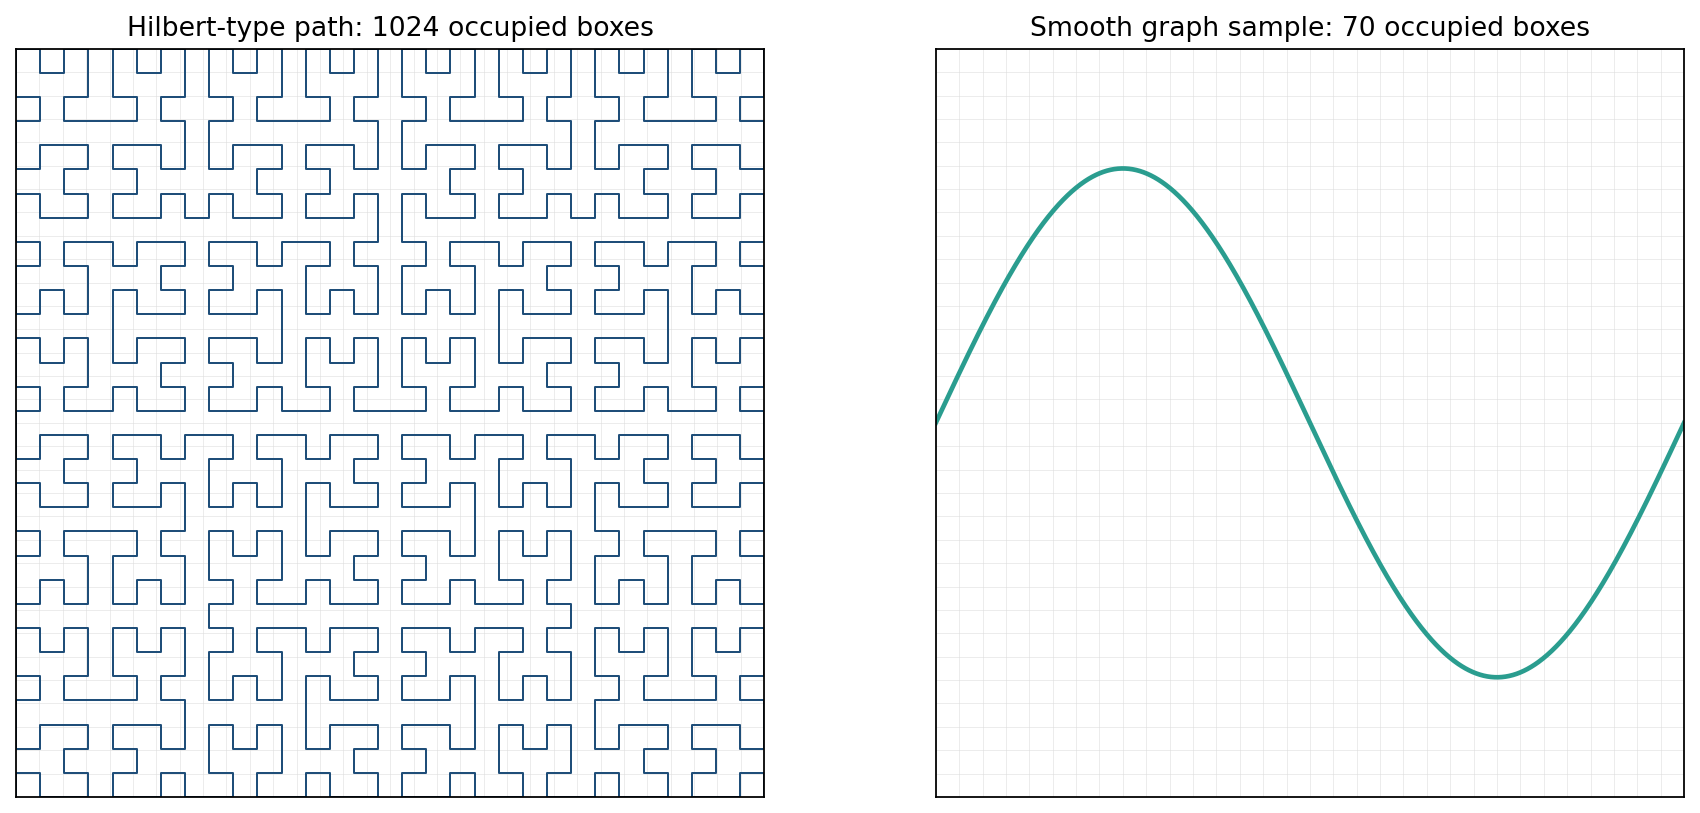

In [9]:
def rot(n, x, y, rx, ry):
    if ry == 0:
        if rx == 1:
            x = n - 1 - x
            y = n - 1 - y
        x, y = y, x
    return x, y

def d2xy(n, d):
    xh = yh = 0
    s_step = 1
    value = d
    while s_step < n:
        rx = 1 & (value // 2)
        ry = 1 & (value ^ rx)
        xh, yh = rot(s_step, xh, yh, rx, ry)
        xh += s_step * rx
        yh += s_step * ry
        value //= 4
        s_step *= 2
    return xh, yh

order = 5
n_grid = 2**order
hilbert = np.array([d2xy(n_grid, d) for d in range(n_grid * n_grid)], dtype=float) / (n_grid - 1)
tau = np.linspace(0, 1, n_grid * n_grid)
smooth_curve = np.column_stack([tau, 0.5 + 0.34 * np.sin(2 * np.pi * tau)])

def occupied_boxes(points, n):
    clipped = np.clip(points, 0, 1 - 1e-12)
    boxes = np.floor(clipped * n).astype(int)
    return {tuple(row) for row in boxes}

hilbert_boxes = occupied_boxes(hilbert, n_grid)
smooth_boxes = occupied_boxes(smooth_curve, n_grid)

fig, (ax_h, ax_s) = plt.subplots(1, 2, figsize=(11.8, 5.2))
ax_h.plot(hilbert[:, 0], hilbert[:, 1], color="#1f4e79", lw=0.9)
ax_h.set_title(f"Hilbert-type path: {len(hilbert_boxes)} occupied boxes")
ax_h.set_aspect("equal")
ax_h.set_xticks([])
ax_h.set_yticks([])
ax_s.plot(smooth_curve[:, 0], smooth_curve[:, 1], color="#2a9d8f", lw=2.1)
ax_s.set_title(f"Smooth graph sample: {len(smooth_boxes)} occupied boxes")
ax_s.set_aspect("equal")
ax_s.set_xticks([])
ax_s.set_yticks([])
for ax in (ax_h, ax_s):
    for val in np.linspace(0, 1, n_grid + 1):
        ax.axhline(val, color="#dddddd", lw=0.25, zorder=0)
        ax.axvline(val, color="#dddddd", lw=0.25, zorder=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
fig.tight_layout()

continuous_warning_path = save_matplotlib(fig, FIGURES / "continuous-vs-smooth-image-box-counts.png")
plt.close(fig)

continuous_warning_checks = {
    "grid_size": n_grid,
    "hilbert_occupied_boxes": len(hilbert_boxes),
    "smooth_curve_occupied_boxes": len(smooth_boxes),
    "hilbert_fraction": len(hilbert_boxes) / (n_grid * n_grid),
    "smooth_fraction": len(smooth_boxes) / (n_grid * n_grid),
    "hilbert_fills_more_than_smooth_graph": bool(len(hilbert_boxes) > 8 * len(smooth_boxes)),
    "warning": "continuous approximations can fill area; smooth rank hypotheses prevent this behavior",
}
continuous_warning_check_path = save_json(continuous_warning_checks, CHECKS / "continuous-counterexample-box-counts.json")
display_artifact(continuous_warning_path, width=880)


## Applied Lab: Scan A Transversality Parameter

The lab below turns the previous family into data. Change the parameter range or
replace `x^2 + a` by another scalar equation. The relevant questions are:

- How many preimage points are present?
- At each preimage point, is the span determinant nonzero?
- Which parameter values are bad, and do they look thin inside the parameter line?


In [10]:
scan_rows = []
for a in np.linspace(-0.8, 0.8, 33):
    if a < -1e-12:
        roots = [-math.sqrt(-a), math.sqrt(-a)]
    elif abs(a) <= 1e-12:
        roots = [0.0]
    else:
        roots = []
    determinants = [-2 * r for r in roots]
    min_abs_det = min([abs(d) for d in determinants], default=None)
    transverse = all(abs(d) > 1e-8 for d in determinants)
    scan_rows.append({
        "a": round(float(a), 3),
        "preimage_count": len(roots),
        "min_abs_span_determinant": None if min_abs_det is None else round(float(min_abs_det), 6),
        "transverse_to_axis": bool(transverse),
    })

scan_path = save_csv(scan_rows, TABLES / "transversality-parameter-scan.csv")
bad_parameters = [row["a"] for row in scan_rows if not row["transverse_to_axis"]]
lab_check_path = save_json(
    {
        "parameter_count": len(scan_rows),
        "bad_parameters": bad_parameters,
        "bad_parameter_count": len(bad_parameters),
        "only_zero_parameter_bad_in_scan": bad_parameters == [0.0],
        "empty_preimages_count_as_transverse": True,
    },
    CHECKS / "transversality-parameter-scan-checks.json",
)
display(pd.DataFrame(scan_rows).head(12))
display(Markdown(f"Saved full scan to `{scan_path.relative_to(BOOK_ROOT)}`."))


,a,preimage_count,min_abs_span_determinant,transverse_to_axis
0,-0.80,2,1.788854,True
1,-0.75,2,1.732051,True
2,-0.70,2,1.673320,True
3,-0.65,2,1.612452,True
4,-0.60,2,1.549193,True
5,-0.55,2,1.483240,True
6,-0.50,2,1.414214,True
7,-0.45,2,1.341641,True
8,-0.40,2,1.264911,True
9,-0.35,2,1.183216,True


Saved full scan to `artifacts\chapter-06-sard-s-theorem\tables\transversality-parameter-scan.csv`.

## Computational Checks

The JSON files record the notebook's claims in a form that can be tested without
rereading the plots: cover areas shrink, regular levels have nonzero sampled
gradient, the Sard proof graph is acyclic, the Whitney projection avoids sampled
bad directions, the retraction returns to radius one, and only the tangent parameter
fails transversality in the lab scan.


In [11]:
check_paths = [
    storyboard_path,
    measure_cover_check_path,
    critical_regular_check_path,
    sard_strata_check_path,
    whitney_projection_check_path,
    approximation_check_path,
    transversality_check_path,
    continuous_warning_check_path,
    lab_check_path,
]
for path in check_paths:
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    print(path.relative_to(BOOK_ROOT), "->", sorted(data.keys())[:5])


artifacts\chapter-06-sard-s-theorem\checks\chapter06_visual_storyboard.json -> ['chapter_goal', 'concept_inventory', 'proof_visualization_strategy', 'source_span_read', 'visual_sequence']
artifacts\chapter-06-sard-s-theorem\checks\measure-zero-cover-checks.json -> ['areas_strictly_decrease_as_epsilon_decreases', 'cover_areas', 'domain_width', 'epsilon_values', 'n_boxes']
artifacts\chapter-06-sard-s-theorem\checks\critical-regular-values-checks.json -> ['critical_solutions', 'critical_value', 'map', 'regular_samples_have_positive_gradient', 'sampled_regular_level_min_gradient_norms']
artifacts\chapter-06-sard-s-theorem\checks\sard-proof-strata-checks.json -> ['domain_dimension_m', 'eventually_negative', 'graph_is_directed_acyclic', 'k_values', 'path_from_charts_to_applications']
artifacts\chapter-06-sard-s-theorem\checks\whitney-projection-checks.json -> ['curve', 'min_cross_norm_secant_vs_kernel', 'min_cross_norm_tangent_vs_kernel', 'projected_speed_min', 'projection_kernel']
artifacts

## Takeaways

- Measure zero is the chapter's language for "thin enough to avoid"; it is stable
  under smooth chart changes in the needed equal-dimensional setting.
- Sard's theorem says the target values produced by critical points are thin, even
  when the critical points themselves are not easy to list.
- Whitney embedding uses that thinness to avoid bad projection directions: do not
  collapse tangents, and do not identify secants.
- Whitney approximation first smooths in Euclidean space, then uses a tubular
  retraction to land back in the manifold.
- Transversality is the span condition that makes preimages and intersections behave
  like submanifolds. Generic perturbations move maps into that good condition.
- Smoothness matters. Without rank control, continuous one-dimensional images can
  display area-filling behavior.


In [12]:
# final_sanity
artifact_paths = [
    routing_path,
    measure_cover_path,
    critical_regular_path,
    sard_strata_path,
    whitney_projection_path,
    approximation_path,
    transversality_static_path,
    transversality_html_path,
    continuous_warning_path,
    scan_path,
    *check_paths,
]
assert_artifacts(artifact_paths, min_bytes=80)

assert measure_zero_checks["areas_strictly_decrease_as_epsilon_decreases"]
assert critical_regular_checks["regular_samples_have_positive_gradient"]
assert sard_strata_checks["graph_is_directed_acyclic"]
assert whitney_projection_checks["sampled_projection_passes"]
assert approximation_checks["homotopy_stays_inside_annulus"]
assert continuous_warning_checks["hilbert_fills_more_than_smooth_graph"]
assert bad_parameters == [0.0]

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": SOURCE_SPAN,
    "artifact_count": len(artifact_paths) + 1,
    "figures": [
        path.name for path in [
            measure_cover_path,
            critical_regular_path,
            sard_strata_path,
            whitney_projection_path,
            approximation_path,
            transversality_static_path,
            continuous_warning_path,
        ]
    ],
    "html": [transversality_html_path.name],
    "tables": [routing_path.name, scan_path.name],
    "checks": [path.name for path in check_paths],
    "core_assertions": {
        "measure_cover_area_decreases": True,
        "regular_values_have_positive_rank_samples": True,
        "sard_proof_graph_acyclic": True,
        "whitney_projection_sample_passes": True,
        "approximation_homotopy_stays_in_tube": True,
        "only_zero_parameter_bad_for_transversality_scan": True,
        "continuous_warning_fills_more_boxes": True,
    },
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=80)
print(f"final_sanity passed for {UNIT_TITLE}: {final_sanity_path.relative_to(BOOK_ROOT)}")


final_sanity passed for Sard's Theorem: artifacts\chapter-06-sard-s-theorem\checks\final_sanity.json
